In [3]:
!pip install xgboost

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [5]:
df = pd.read_csv(r"C:\Users\raj\F1-Performance-Prediction-System\Data Set\Processed\F1_Data_With_Feature_Engineering.csv")

df.head()

,Season,Round,Race,Driver,Team,LapNumber,LapTime,Sector1Time,Sector2Time,Sector3Time,...,Position,TrackStatus,RacePhase,IsSoft,TyreAge,PitStop,DriverAvgLap,TeamAvgLap,PositionGroup,TrackCondition
0,2018,3,Chinese Grand Prix,RIC,Red Bull Racing,2.0,100.480,26.789,30.247,43.444,...,6.0,1.0,Early,0,Fresh,0,90.84431,90.305663,Points,Green Flag
1,2018,3,Chinese Grand Prix,RIC,Red Bull Racing,3.0,100.059,26.645,30.241,43.173,...,6.0,1.0,Early,0,Fresh,0,90.84431,90.305663,Points,Green Flag
2,2018,3,Chinese Grand Prix,RIC,Red Bull Racing,4.0,100.085,26.764,30.243,43.078,...,6.0,1.0,Early,0,Fresh,0,90.84431,90.305663,Points,Green Flag
3,2018,3,Chinese Grand Prix,RIC,Red Bull Racing,5.0,99.715,26.655,30.072,42.988,...,6.0,1.0,Early,0,Fresh,0,90.84431,90.305663,Points,Green Flag
4,2018,3,Chinese Grand Prix,RIC,Red Bull Racing,6.0,99.225,26.595,29.895,42.735,...,6.0,1.0,Early,0,Fresh,0,90.84431,90.305663,Points,Green Flag


In [12]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Race",
    "Driver",
    "Team",
    "Compound",
    "RacePhase",
    "TyreAge",
    "PositionGroup",
    "TrackCondition"
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

In [13]:
X = df.drop(
    columns=[
        "LapTime",
        "Sector1Time",
        "Sector2Time",
        "Sector3Time"
    ]
)

y = df["LapTime"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, lr_pred)
rmse = root_mean_squared_error(y_test, lr_pred)
r2 = r2_score(y_test, lr_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 10.121
RMSE: 12.594
R²  : 0.202


In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, rf_pred)
rmse = root_mean_squared_error(y_test, rf_pred)
r2 = r2_score(y_test, rf_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 0.883
RMSE: 2.494
R²  : 0.969


In [24]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

mae = mean_absolute_error(y_test, xgb_pred)
rmse = root_mean_squared_error(y_test, xgb_pred)
r2 = r2_score(y_test, xgb_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 1.301
RMSE: 2.854
R²  : 0.959


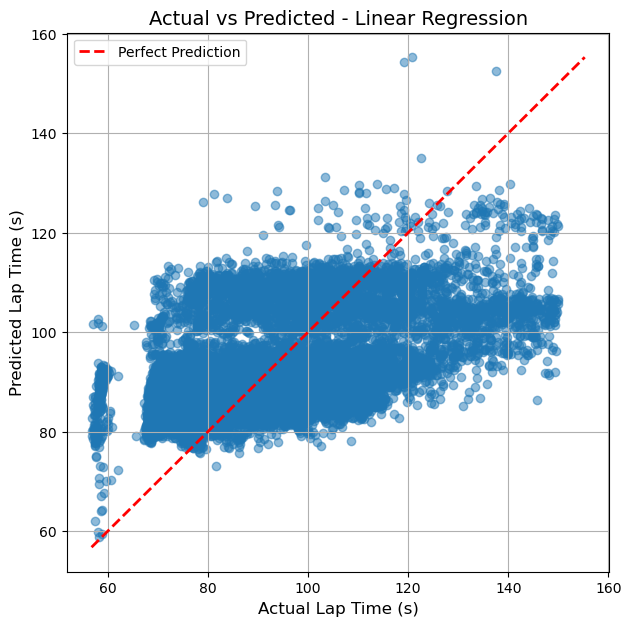

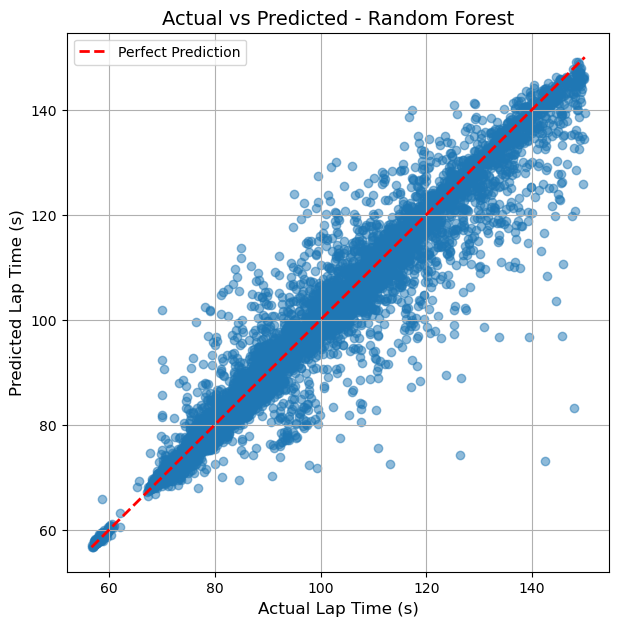

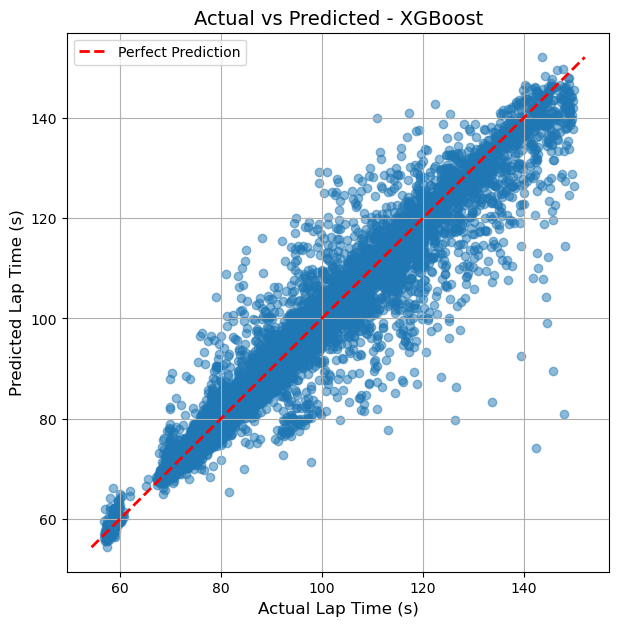

In [27]:
import matplotlib.pyplot as plt

# Store predictions
predictions = {
    "Linear Regression": lr.predict(X_test),
    "Random Forest": rf.predict(X_test),
    "XGBoost": xgb.predict(X_test)
}

# Plot each model separately
for model_name, y_pred in predictions.items():

    plt.figure(figsize=(7, 7))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.5
    )

    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='red',
        linestyle='--',
        linewidth=2,
        label='Perfect Prediction'
    )

    plt.title(f'Actual vs Predicted - {model_name}', fontsize=14)
    plt.xlabel('Actual Lap Time (s)', fontsize=12)
    plt.ylabel('Predicted Lap Time (s)', fontsize=12)
    plt.legend()
    plt.grid(True)

    # Save image
    filename = model_name.lower().replace(" ", "_") + "_actual_vs_predicted.png"

    plt.show()
    plt.close()

In [28]:
import joblib

best_model = models[results_df.iloc[0]["Model"]]

joblib.dump(best_model, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!
